# RF-DETR Probe Detection — Balanced Dataset Training

**Complete pipeline:** dataset inspection → training → evaluation → predictions

## 1. Setup

In [ ]:
%pip install rfdetr[train,loggers] supervision opencv-python-headless tqdm matplotlib --quiet

In [1]:
import os, json, random
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
from rfdetr import RFDETRSmall, RFDETRLarge, from_checkpoint

# Verify GPU
if not torch.cuda.is_available():
    raise RuntimeError('No CUDA detected')

DEVICE = 'cuda'
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

GPU: NVIDIA GeForce RTX 5090
VRAM: 34.2 GB


In [2]:
# Paths
HERE = os.path.abspath('')
DATASET_DIR = os.path.join(HERE, 'latest_dataset')
RUNS_DIR = os.path.join(HERE, 'runs_latest')

os.makedirs(RUNS_DIR, exist_ok=True)

# Config
CATEGORIES = [
    {'id': 1, 'name': 'BODY', 'supercategory': 'probe'},
    {'id': 2, 'name': 'TAIL', 'supercategory': 'probe'},
]
CLASS_COLORS = {1: '#00ff00', 2: '#ff0000'}
CLASS_NAMES = {1: 'BODY', 2: 'TAIL'}

print(f'Dataset: {DATASET_DIR}')
print(f'Runs: {RUNS_DIR}')

Dataset: c:\Users\Krish\Desktop\scanner-annotation\REDetr_Probe_Detection_Training\latest_dataset
Runs: c:\Users\Krish\Desktop\scanner-annotation\REDetr_Probe_Detection_Training\runs_latest


## 2. Dataset Stats & Visualization

In [3]:
def load_coco(split):
    with open(os.path.join(DATASET_DIR, split, '_annotations.coco.json')) as f:
        return json.load(f)

stats = {}
for split in ('train', 'valid', 'test'):
    coco = load_coco(split)
    stats[split] = {
        'images': len(coco['images']),
        'body': sum(1 for a in coco['annotations'] if a['category_id'] == 1),
        'tail': sum(1 for a in coco['annotations'] if a['category_id'] == 2),
    }

print(f'{"split":8s}  {"images":>8s}  {"BODY":>8s}  {"TAIL":>8s}  {"ratio":>8s}')
print('-' * 50)
for s in ('train', 'valid', 'test'):
    b, t = stats[s]['body'], stats[s]['tail']
    ratio = t / max(b, 1)
    print(f'{s:8s}  {stats[s]["images"]:8d}  {b:8d}  {t:8d}  {ratio:8.2f}x')

split       images      BODY      TAIL     ratio
--------------------------------------------------
train         4243      3545      3553      1.00x
valid         1196       864      1098      1.27x
test          1704      1534      1407      0.92x


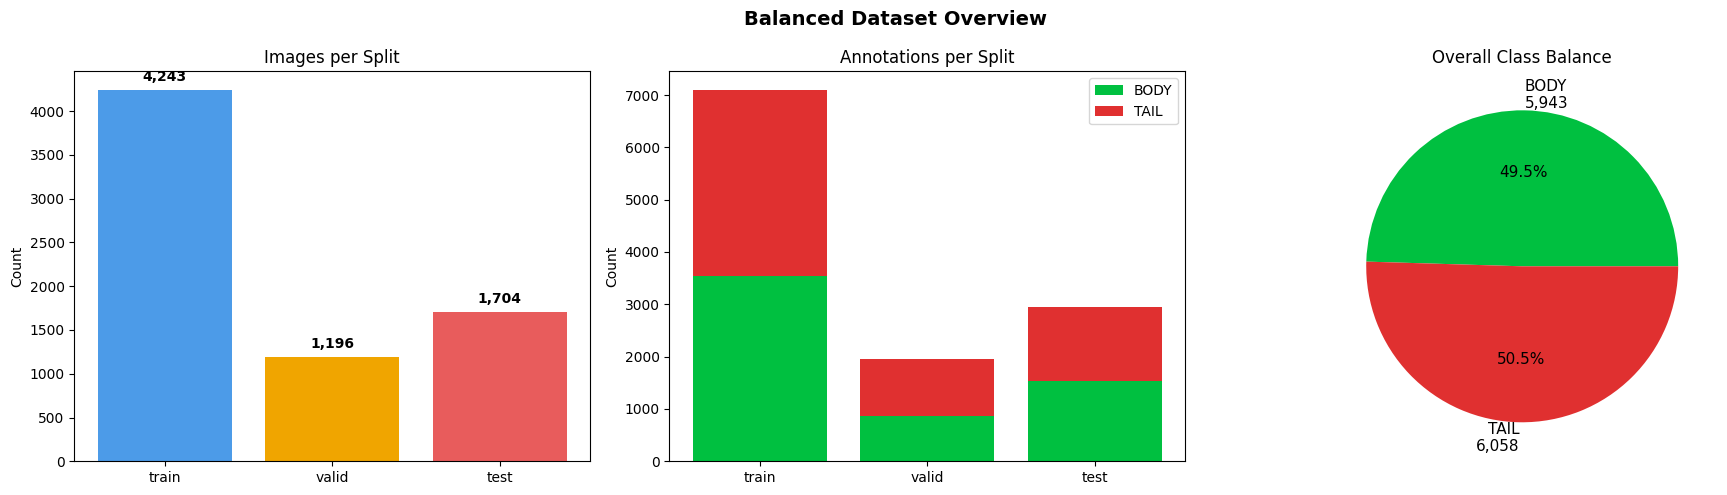

In [4]:
# Overview charts
splits = ['train', 'valid', 'test']
body_counts = [stats[s]['body'] for s in splits]
tail_counts = [stats[s]['tail'] for s in splits]
img_counts = [stats[s]['images'] for s in splits]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Balanced Dataset Overview', fontsize=14, fontweight='bold')

# Images
axes[0].bar(splits, img_counts, color=['#4c9be8', '#f0a500', '#e85c5c'])
for i, v in enumerate(img_counts):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Images per Split')
axes[0].set_ylabel('Count')

# Stacked BODY / TAIL
x = np.arange(len(splits))
axes[1].bar(x, body_counts, label='BODY', color='#00c040')
axes[1].bar(x, tail_counts, bottom=body_counts, label='TAIL', color='#e03030')
axes[1].set_xticks(x)
axes[1].set_xticklabels(splits)
axes[1].set_title('Annotations per Split')
axes[1].set_ylabel('Count')
axes[1].legend()

# Class balance pie
total_body = sum(body_counts)
total_tail = sum(tail_counts)
axes[2].pie([total_body, total_tail],
            labels=[f'BODY\n{total_body:,}', f'TAIL\n{total_tail:,}'],
            colors=['#00c040', '#e03030'],
            autopct='%1.1f%%',
            textprops={'fontsize': 11})
axes[2].set_title('Overall Class Balance')

plt.tight_layout()
plt.savefig(os.path.join(HERE, 'dataset_stats.png'), dpi=100, bbox_inches='tight')
plt.show()

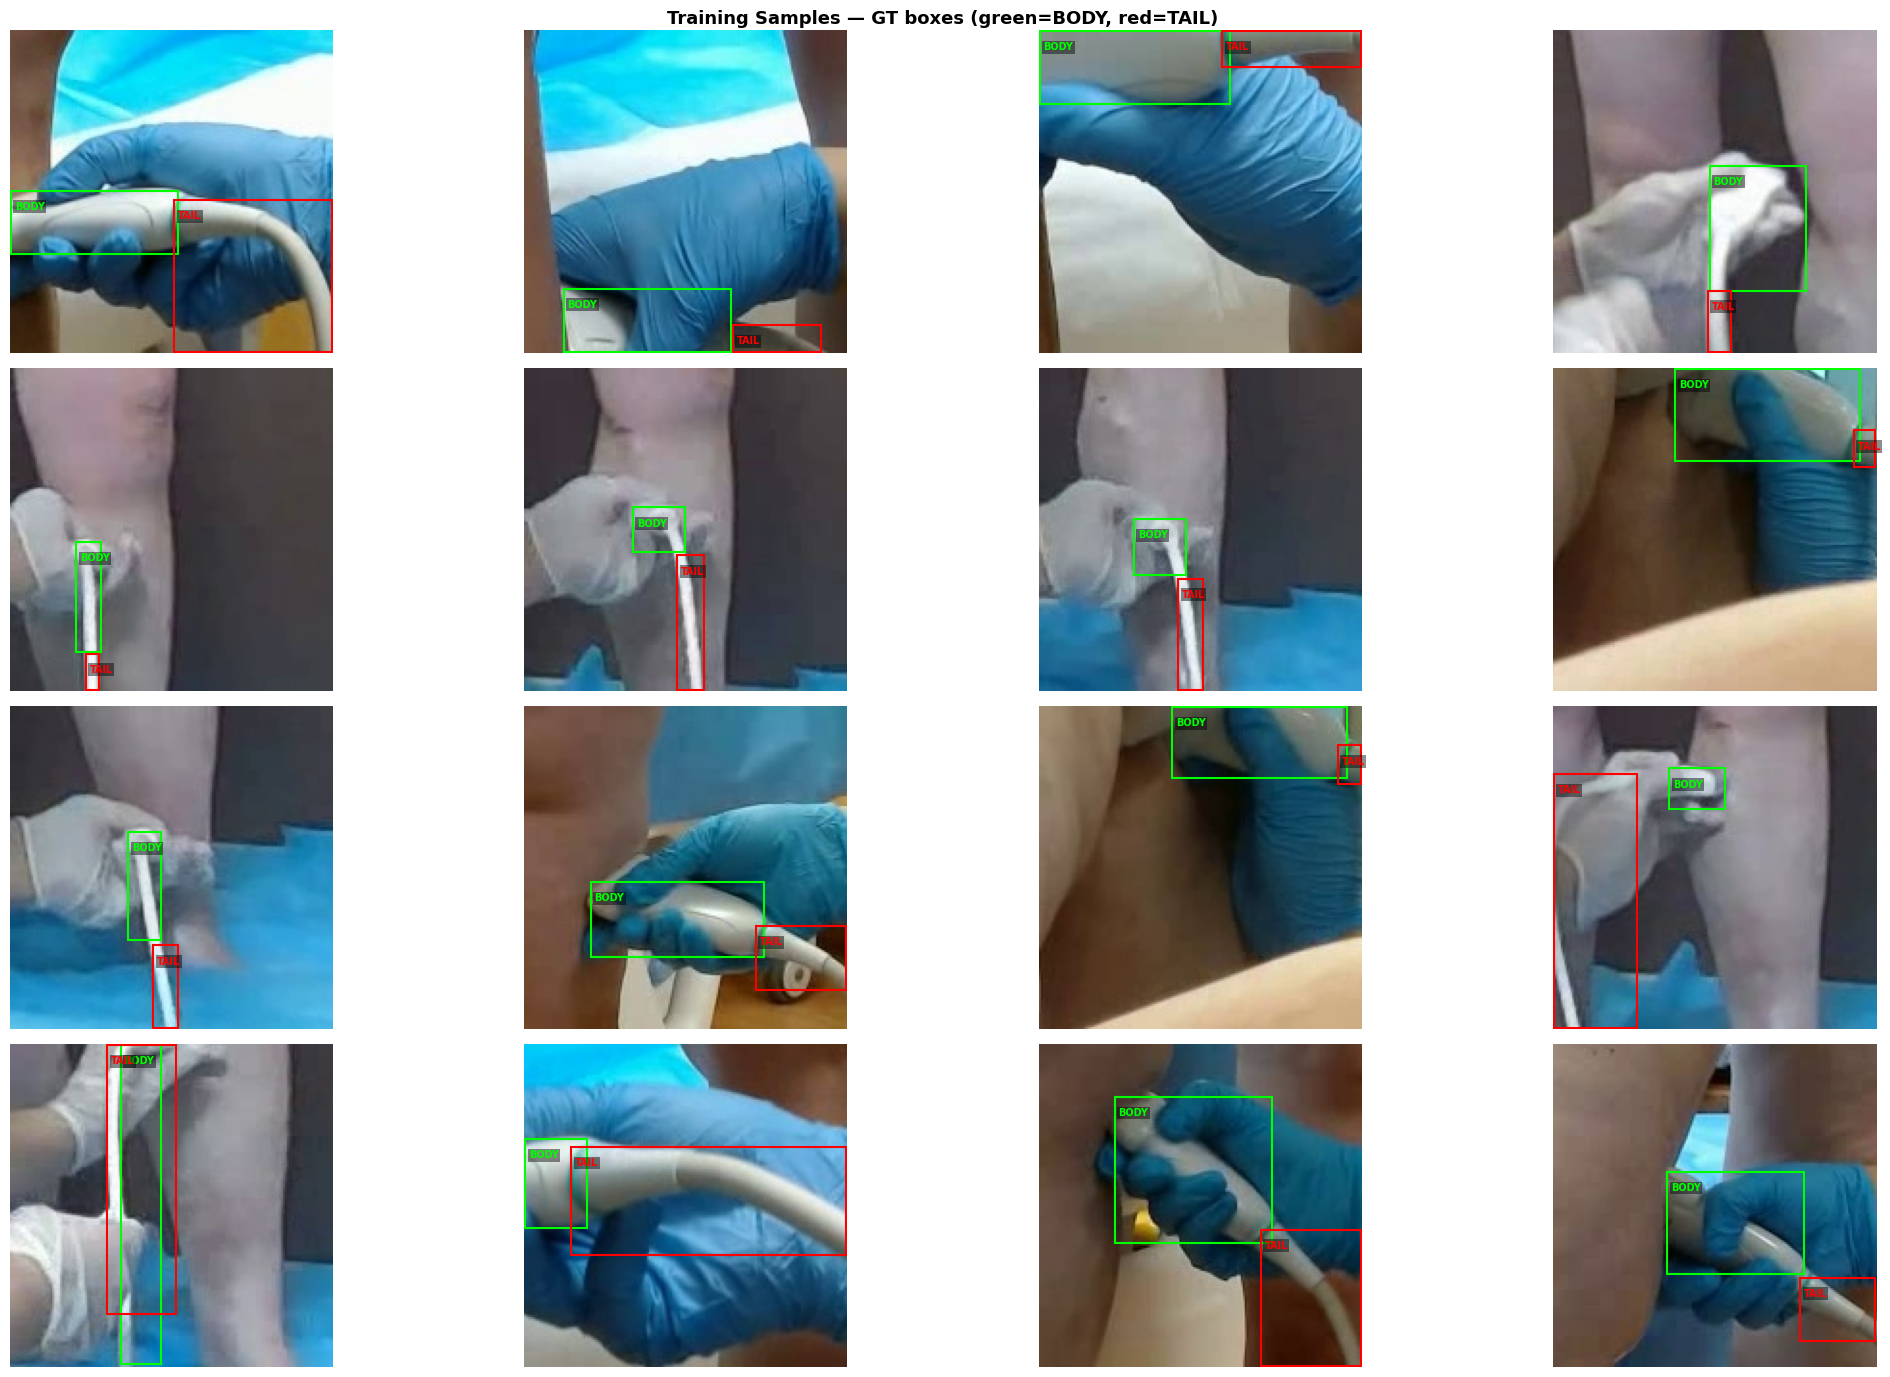

In [5]:
# Sample grid with GT boxes
coco_train = load_coco('train')
id2img = {i['id']: i for i in coco_train['images']}
img2anns = defaultdict(list)
for a in coco_train['annotations']:
    img2anns[a['image_id']].append(a)

both_ids = [iid for iid, anns in img2anns.items()
            if any(a['category_id'] == 1 for a in anns)
            and any(a['category_id'] == 2 for a in anns)]
sample_ids = random.sample(both_ids, min(16, len(both_ids)))

fig, axes = plt.subplots(4, 4, figsize=(22, 14))
fig.suptitle('Training Samples — GT boxes (green=BODY, red=TAIL)', fontsize=13, fontweight='bold')

for ax, iid in zip(axes.flat, sample_ids):
    info = id2img[iid]
    img_bgr = cv2.imread(os.path.join(DATASET_DIR, 'train', info['file_name']))
    ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    for ann in img2anns[iid]:
        x, y, w, h = ann['bbox']
        cat = ann['category_id']
        ax.add_patch(mpatches.Rectangle((x, y), w, h,
                     linewidth=1.5, edgecolor=CLASS_COLORS[cat], facecolor='none'))
        ax.text(x + 2, y + 10, CLASS_NAMES[cat],
                color=CLASS_COLORS[cat], fontsize=7, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.45, pad=1, edgecolor='none'))
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(HERE, 'sample_grid.png'), dpi=100, bbox_inches='tight')
plt.show()

## 3. Train RF-DETR Small (30 epochs)

In [6]:
model = RFDETRSmall(
    num_classes=len(CATEGORIES),
    resolution=560,
    device=DEVICE,
)

model.train(
    dataset_dir=DATASET_DIR,
    epochs=10,
    batch_size=16,
    lr=5e-4,
    output_dir=RUNS_DIR,
    dataset_file='roboflow',
    checkpoint_interval=5,
)

[2026-09-07 17:42:59] [INFO] rf-detr - File C:\Users\Krish\.roboflow\models\rf-detr-small.pth already exists with correct MD5 hash.


[2026-09-07 17:42:59] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-07 17:42:59] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-07 17:42:59] [INFO] rf-detr - File C:\Users\Krish\.roboflow\models\rf-detr-small.pth already exists with correct MD5 hash.


[2026-09-07 17:43:00] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 2. The detection head will be re-initialized to 2 classes.
W0907 17:43:00.860000 20452 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
[2026-09-07 17:43:00] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-07 17:43:00] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-07 17:43:01] [INFO] rf-detr - File C:\Users\Krish\.roboflow\models\rf-detr-small.pth already exists with correct MD5 hash.


...

[2026-09-07 17:45:25] [INFO] rf-detr - Best regular checkpoint saved to C:\Users\Krish\Desktop\scanner-annotation\REDetr_Probe_Detection_Training\runs_latest\checkpoint_best_regular.pth (epoch 0, monitor=val/mAP_50_95, value=0.29357)
[2026-09-07 17:45:25] [INFO] rf-detr - Best EMA mAP improved to 0.2986 (epoch 0)


[2026-09-07 17:47:29] [INFO] rf-detr - Best regular checkpoint saved to C:\Users\Krish\Desktop\scanner-annotation\REDetr_Probe_Detection_Training\runs_latest\checkpoint_best_regular.pth (epoch 1, monitor=val/mAP_50_95, value=0.317198)
[2026-09-07 17:47:29] [INFO] rf-detr - Best EMA mAP improved to 0.3236 (epoch 1)


[2026-09-07 18:04:13] [INFO] rf-detr - Best regular checkpoint saved to C:\Users\Krish\Desktop\scanner-annotation\REDetr_Probe_Detection_Training\runs_latest\checkpoint_best_regular.pth (epoch 9, monitor=val/mAP_50_95, value=0.318421)


`Trainer.fit` stopped: `max_epochs=10` reached.


[2026-09-07 18:04:19] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.3184, ema=0.3236)


## 4.1 Preliminary Evaluation on Test Set for Body MAP Checking

In [9]:
from rfdetr import from_checkpoint
import json

ckpt_path = os.path.join(RUNS_DIR, 'checkpoint_best_total.pth')
eval_model = from_checkpoint(ckpt_path)

results = eval_model.evaluate(
    dataset_dir=DATASET_DIR,
    dataset_file='roboflow',
    device=DEVICE,
)

print("Test Set Results:")
print(f"  mAP@50:95: {results.get('test/mAP_50_95', 0):.4f}")
print(f"  mAP@50:    {results.get('test/mAP_50', 0):.4f}")
print(f"  BODY AP:   {results.get('test/AP/BODY', 0):.4f}")
print(f"  TAIL AP:   {results.get('test/AP/TAIL', 0):.4f}")
print(f"\n{json.dumps(results, indent=2)}")

[2026-09-07 18:13:00] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-07 18:13:00] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-07 18:13:00] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-07 18:13:00] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-07 18:13:01] [INFO] rf-detr - Building Roboflow test dataset with square resize at resolution 512
[2026-09-07 18:13:01] [INFO] rf-detr - Using multi-scale training with square resize and scales: [672]


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


c:\Users\Krish\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/AP/BODY        │    0.8609351515769958     │
│       test/AP/TAIL        │    0.8235483169555664     │
│          test/F1          │    0.9328112602233887     │
│         test/loss         │    3.7757034301757812     │
│        test/mAP_50        │    0.9637234807014465     │
│      test/mAP_50_95       │    0.8422417640686035     │
│        test/mAP_75        │    0.9226102828979492     │
│         test/mAR          │    0.9256670475006104     │
│      test/precision       │    0.9432856440544128     │
│        test/recall        │    0.9226518273353577     │
└───────────────────────────┴───────────────────────────┘

Test Set Results:
  mAP@50:95: 0.8422
  mAP@50:    0.9637
  BODY AP:   0.8609
  TAIL AP:   0.8235

{
  "test/loss": 3.7757034301757812,
  "test/mAP_50_95": 0.8422417640686035,
  "test/mAP_50": 0.9637234807014465,
  "test/mAP_75": 0.9226102828979492,
  "test/mAR": 0.9256670475006104,
  "test/F1": 0.9328112602233887,
  "test/precision": 0.9432856440544128,
  "test/recall": 0.9226518273353577,
  "test/AP/BODY": 0.8609351515769958,
  "test/AP/TAIL": 0.8235483169555664
}


## 4.2 Full Evaluation on Test Set

In [7]:
ckpt_path = os.path.join(RUNS_DIR, 'checkpoint_best_total.pth')
eval_model = from_checkpoint(ckpt_path)

results = eval_model.evaluate(
    dataset_dir=DATASET_DIR,
    dataset_file='roboflow',
    device=DEVICE,
)

print(json.dumps(results, indent=2))

c:\Users\Krish\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\rfdetr\detr.py:551: FutureWarning: The `RFDETRBase` was deprecated since v1.7.0. It will be removed in v2.0.0.
  getattr(variant_obj, "__name__", symbol): variant_obj
c:\Users\Krish\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\rfdetr\detr.py:551: FutureWarning: The `RFDETRLargeDeprecated` was deprecated since v1.7.0. It will be removed in v2.0.0.
  getattr(variant_obj, "__name__", symbol): variant_obj
c:\Users\Krish\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\rfdetr\detr.py:551: FutureWarning: The `RFDETRSegPreview` was deprecated since v1.7.0. It will be removed in v2.0.0.
  getattr(variant_obj, "__name__", symbol): variant_obj
[2026-09-07 18:11:07] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-07 18:11:07] [WARNING] rf-detr 

[2026-09-07 18:11:07] [INFO] rf-detr - Building Roboflow test dataset with square resize at resolution 512
[2026-09-07 18:11:07] [INFO] rf-detr - Using multi-scale training with square resize and scales: [672]


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


c:\Users\Krish\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/AP/BODY        │    0.8609351515769958     │
│       test/AP/TAIL        │    0.8235483169555664     │
│          test/F1          │    0.9328112602233887     │
│         test/loss         │    3.7757034301757812     │
│        test/mAP_50        │    0.9637234807014465     │
│      test/mAP_50_95       │    0.8422417640686035     │
│        test/mAP_75        │    0.9226102828979492     │
│         test/mAR          │    0.9256670475006104     │
│      test/precision       │    0.9432856440544128     │
│        test/recall        │    0.9226518273353577     │
└───────────────────────────┴───────────────────────────┘

{
  "test/loss": 3.7757034301757812,
  "test/mAP_50_95": 0.8422417640686035,
  "test/mAP_50": 0.9637234807014465,
  "test/mAP_75": 0.9226102828979492,
  "test/mAR": 0.9256670475006104,
  "test/F1": 0.9328112602233887,
  "test/precision": 0.9432856440544128,
  "test/recall": 0.9226518273353577,
  "test/AP/BODY": 0.8609351515769958,
  "test/AP/TAIL": 0.8235483169555664
}


## 5. Predictions on Test Images

[2026-09-07 18:12:08] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.inference(dtype=torch.float16).


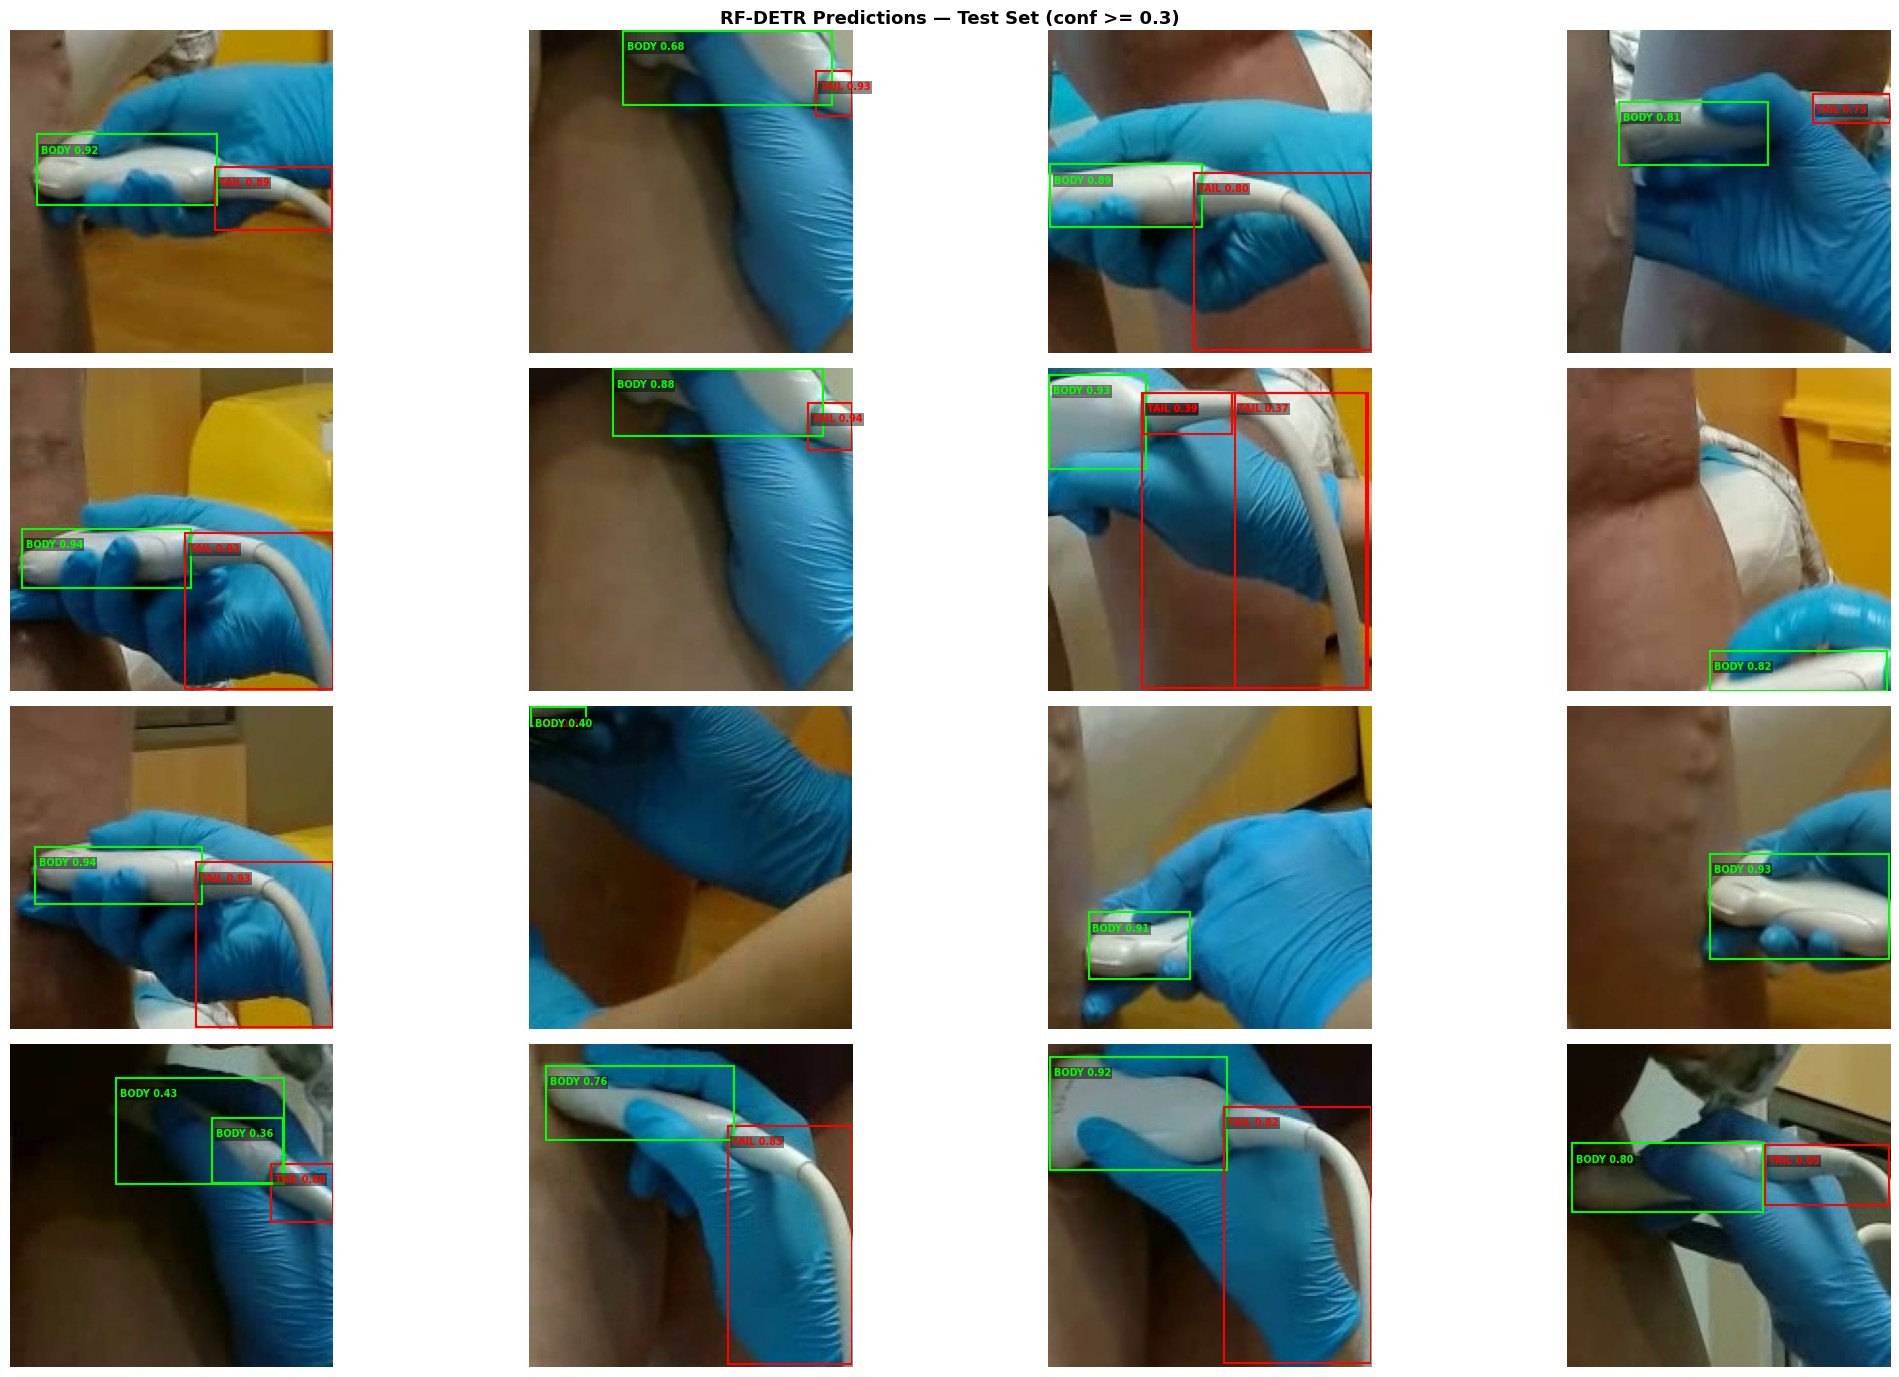

In [8]:
CONF_THRESH = 0.3

coco_test = load_coco('test')
sample_test = random.sample(coco_test['images'], min(16, len(coco_test['images'])))

fig, axes = plt.subplots(4, 4, figsize=(22, 14))
fig.suptitle(f'RF-DETR Predictions — Test Set (conf >= {CONF_THRESH})', fontsize=13, fontweight='bold')

for ax, info in zip(axes.flat, sample_test):
    img_path = os.path.join(DATASET_DIR, 'test', info['file_name'])
    img_bgr = cv2.imread(img_path)
    ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))

    dets = eval_model.predict(img_path, threshold=CONF_THRESH)
    if dets is not None and len(dets.xyxy) > 0:
        for box, cls_id, conf in zip(dets.xyxy, dets.class_id, dets.confidence):
            x0, y0, x1, y1 = box
            cat = int(cls_id) + 1
            color = CLASS_COLORS.get(cat, 'white')
            ax.add_patch(mpatches.Rectangle(
                (x0, y0), x1 - x0, y1 - y0,
                linewidth=1.5, edgecolor=color, facecolor='none'))
            ax.text(x0 + 2, y0 + 10, f"{CLASS_NAMES.get(cat, cat)} {conf:.2f}",
                    color=color, fontsize=7, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.45, pad=1, edgecolor='none'))
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(HERE, 'predictions_test.png'), dpi=100, bbox_inches='tight')
plt.show()